# Retail Demand Forecasting & Inventory Optimisation

**End-to-end retail decision system: forecast SKU demand, quantify uncertainty, and convert forecasts into replenishment targets.**

### Business questions
1. What will each high-volume SKU sell next?
2. Does machine learning beat a seasonal-naive forecast?
3. Which products create the largest forecast errors and stock-out risk?
4. How much safety stock is justified by forecast uncertainty?
5. Can a forecast-driven policy reduce simulated stock-outs without excessive inventory?

### Real dataset
This notebook uses the **UCI Online Retail** dataset: 541,909 transactions from a UK-based online retailer between December 2010 and December 2011.

### Modelling stack
- strict chronological train / validation / test split
- lagged and rolling demand features
- seasonal-naive baseline
- Extra Trees regression
- XGBoost regression
- WMAPE, MAE and RMSE evaluation
- feature importance + SHAP
- 7-day inventory simulation
- safety stock and reorder-point recommendations

Customer identifiers are not used in the forecasting model.

In [1]:
# Colab / GitHub Actions safe setup
import sys, subprocess, importlib.util

required = {
    "openpyxl": "openpyxl",
    "xgboost": "xgboost",
    "shap": "shap"
}
for module, package in required.items():
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("Environment ready.")

Environment ready.


In [2]:
import warnings, zipfile, urllib.request
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported.")

Libraries imported.


## 1. Download the real UCI Online Retail dataset

The source file is downloaded directly from the UCI Machine Learning Repository. No synthetic sales data is used.

In [3]:
DATA_URL = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
zip_path = Path("online_retail.zip")
extract_dir = Path("online_retail_data")

if not zip_path.exists():
    urllib.request.urlretrieve(DATA_URL, zip_path)

extract_dir.mkdir(exist_ok=True)
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_dir)

xlsx_files = list(extract_dir.rglob("*.xlsx"))
if not xlsx_files:
    raise FileNotFoundError("UCI Online Retail Excel file was not found.")

raw = pd.read_excel(xlsx_files[0], engine="openpyxl")

print(f"Raw rows: {len(raw):,}")
print(f"Columns: {raw.columns.tolist()}")
print(f"Date range: {raw['InvoiceDate'].min()} -> {raw['InvoiceDate'].max()}")
display(raw.head())

Raw rows: 541,909
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Date range: 2010-12-01 08:26:00 -> 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.550,"17,850.000",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.390,"17,850.000",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.750,"17,850.000",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.390,"17,850.000",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.390,"17,850.000",United Kingdom


## 2. Retail data quality and transaction cleaning

Cancellations, returns, non-positive prices, missing product descriptions and non-product administrative stock codes are removed before demand modelling.

In [4]:
df = raw.copy()

df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

clean = df.loc[
    ~df["InvoiceNo"].str.upper().str.startswith("C")
    & df["InvoiceDate"].notna()
    & df["Description"].notna()
    & (df["Quantity"] > 0)
    & (df["UnitPrice"] > 0)
    & (df["Country"] == "United Kingdom")
].copy()

# Keep standard merchandise stock codes; remove postage/manual adjustment rows.
clean = clean.loc[clean["StockCode"].str.match(r"^\d{5}[A-Z]?$", na=False)].copy()
clean["date"] = clean["InvoiceDate"].dt.floor("D")
clean["revenue"] = clean["Quantity"] * clean["UnitPrice"]

print(f"Clean UK merchandise rows: {len(clean):,}")
print(f"Unique products: {clean['StockCode'].nunique():,}")
print(f"Positive units sold: {int(clean['Quantity'].sum()):,}")
print(f"Observed revenue: £{clean['revenue'].sum():,.2f}")
print(f"CustomerID used as a model feature: {'CustomerID' in []}")

quality = pd.DataFrame({
    "missing": clean.isna().sum(),
    "unique": clean.nunique(dropna=False)
})
display(quality)

Clean UK merchandise rows: 481,770
Unique products: 3,782
Positive units sold: 4,646,942
Observed revenue: £8,703,448.62
CustomerID used as a model feature: False


,missing,unique
InvoiceNo,0,17897
StockCode,0,3782
Description,0,3983
Quantity,0,368
InvoiceDate,0,16693
UnitPrice,0,495
CustomerID,128014,3917
Country,0,1
date,0,305
revenue,0,4029


## 3. Select high-volume SKUs and create a complete daily demand panel

The project focuses on the 20 highest-volume merchandise SKUs. Missing product-days are explicitly represented as zero demand rather than silently disappearing.

In [5]:
description_map = (
    clean.groupby("StockCode")["Description"]
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
)

top_codes = (
    clean.groupby("StockCode")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .index
)

daily = (
    clean.loc[clean["StockCode"].isin(top_codes)]
    .groupby(["date","StockCode"], as_index=False)
    .agg(
        demand=("Quantity","sum"),
        revenue=("revenue","sum"),
        median_price=("UnitPrice","median")
    )
)

all_dates = pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
grid = pd.MultiIndex.from_product(
    [all_dates, top_codes],
    names=["date","StockCode"]
).to_frame(index=False)

panel = grid.merge(daily, on=["date","StockCode"], how="left")
panel["demand"] = panel["demand"].fillna(0.0)
panel["revenue"] = panel["revenue"].fillna(0.0)

product_median_price = clean.groupby("StockCode")["UnitPrice"].median()
panel["median_price"] = (
    panel["median_price"]
    .fillna(panel["StockCode"].map(product_median_price))
)

panel["Description"] = panel["StockCode"].map(description_map)

product_summary = (
    panel.groupby(["StockCode","Description"])
    .agg(
        total_units=("demand","sum"),
        active_days=("demand", lambda s: int((s > 0).sum())),
        avg_daily_units=("demand","mean"),
        demand_std=("demand","std")
    )
    .sort_values("total_units", ascending=False)
)

print(f"Daily panel rows: {len(panel):,}")
print(f"Products modelled: {panel['StockCode'].nunique()}")
print(f"Days modelled: {panel['date'].nunique()}")
display(product_summary.head(10))

Daily panel rows: 7,480
Products modelled: 20
Days modelled: 374


,,total_units,active_days,avg_daily_units,demand_std
StockCode,Description,,,,
23843,"PAPER CRAFT , LITTLE BIRDIE","80,995.000",1,216.564,"4,188.152"
23166,MEDIUM CERAMIC TOP STORAGE JAR,"77,036.000",120,205.979,"3,837.255"
22197,POPCORN HOLDER,"53,343.000",291,142.628,373.246
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"49,526.000",223,132.422,391.714
85099B,JUMBO BAG RED RETROSPOT,"44,264.000",300,118.353,175.478
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"35,509.000",305,94.944,222.425
84879,ASSORTED COLOUR BIRD ORNAMENT,"33,735.000",298,90.201,206.219
22616,PACK OF 12 LONDON TISSUES,"25,127.000",236,67.184,187.861
21212,PACK OF 72 RETROSPOT CAKE CASES,"24,986.000",294,66.807,130.030


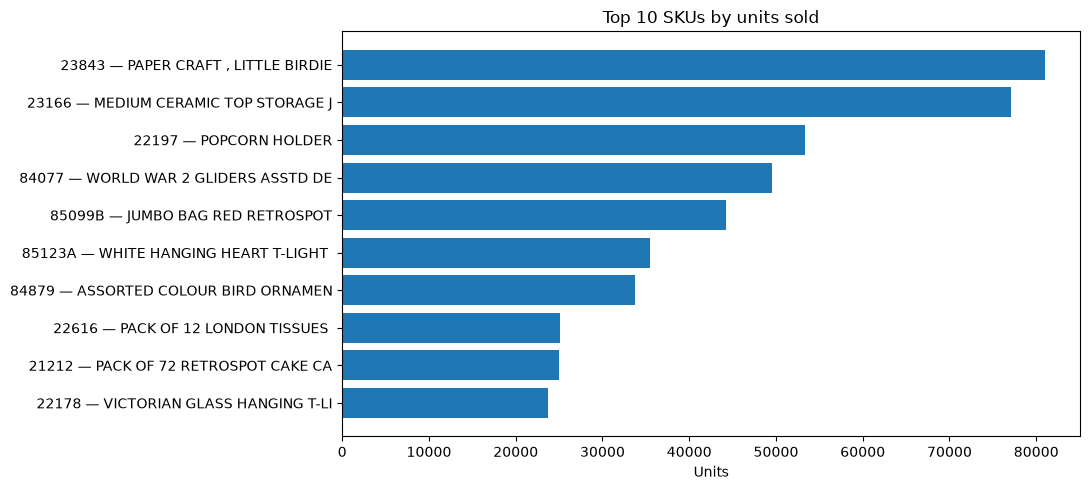

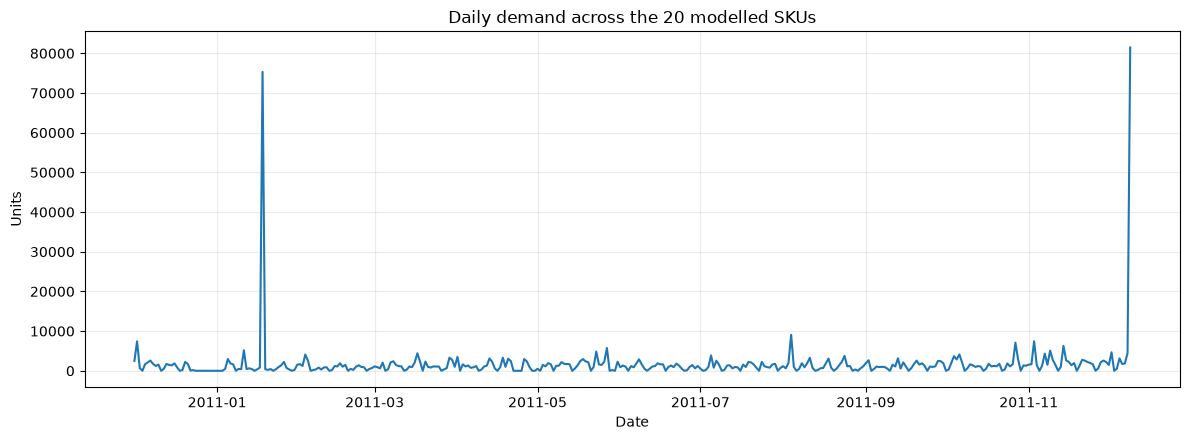

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
top10 = product_summary.head(10).sort_values("total_units")
ax.barh(
    [f"{idx[0]} — {idx[1][:28]}" for idx in top10.index],
    top10["total_units"]
)
ax.set_title("Top 10 SKUs by units sold")
ax.set_xlabel("Units")
plt.tight_layout()
plt.show()

daily_total = panel.groupby("date")["demand"].sum()
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(daily_total.index, daily_total.values)
ax.set_title("Daily demand across the 20 modelled SKUs")
ax.set_ylabel("Units")
ax.set_xlabel("Date")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Leakage-safe demand features

Every demand feature is shifted, so it uses only information that existed **before** the day being predicted.

In [7]:
panel = panel.sort_values(["StockCode","date"]).reset_index(drop=True)

g = panel.groupby("StockCode", group_keys=False)

for lag in [1, 2, 7, 14, 28]:
    panel[f"lag_{lag}"] = g["demand"].shift(lag)

for window in [7, 14, 28]:
    panel[f"rolling_mean_{window}"] = g["demand"].transform(
        lambda s: s.shift(1).rolling(window).mean()
    )
    panel[f"rolling_std_{window}"] = g["demand"].transform(
        lambda s: s.shift(1).rolling(window).std()
    )

panel["zero_demand_rate_28"] = g["demand"].transform(
    lambda s: s.shift(1).rolling(28).apply(lambda x: np.mean(x == 0), raw=True)
)
panel["lag_price_1"] = g["median_price"].shift(1)

panel["dow"] = panel["date"].dt.dayofweek
panel["week"] = panel["date"].dt.isocalendar().week.astype(int)
panel["month"] = panel["date"].dt.month
panel["day_of_month"] = panel["date"].dt.day
panel["is_weekend"] = (panel["dow"] >= 5).astype(int)
panel["dow_sin"] = np.sin(2*np.pi*panel["dow"]/7)
panel["dow_cos"] = np.cos(2*np.pi*panel["dow"]/7)
panel["month_sin"] = np.sin(2*np.pi*panel["month"]/12)
panel["month_cos"] = np.cos(2*np.pi*panel["month"]/12)

model_df = panel.dropna().copy()

print(f"Rows after lag/rolling warm-up: {len(model_df):,}")
print("Forecast target: demand")
print("All demand history variables are shifted by at least one day.")

Rows after lag/rolling warm-up: 6,920
Forecast target: demand
All demand history variables are shifted by at least one day.


## 5. Strict chronological train / validation / test design

The final 60 days are held out for testing. The preceding 45 days are validation data used for model selection.

In [8]:
max_date = model_df["date"].max()
test_start = max_date - pd.Timedelta(days=59)
val_start = test_start - pd.Timedelta(days=45)

train_df = model_df.loc[model_df["date"] < val_start].copy()
val_df = model_df.loc[
    (model_df["date"] >= val_start) & (model_df["date"] < test_start)
].copy()
test_df = model_df.loc[model_df["date"] >= test_start].copy()

numeric_features = [
    "lag_1","lag_2","lag_7","lag_14","lag_28",
    "rolling_mean_7","rolling_mean_14","rolling_mean_28",
    "rolling_std_7","rolling_std_14","rolling_std_28",
    "zero_demand_rate_28","lag_price_1",
    "dow","week","month","day_of_month","is_weekend",
    "dow_sin","dow_cos","month_sin","month_cos"
]

def make_matrix(frame):
    base = frame[numeric_features + ["StockCode"]].copy()
    return pd.get_dummies(base, columns=["StockCode"], prefix="sku", dtype=float)

X_all = make_matrix(model_df)
all_columns = X_all.columns.tolist()

def matrix_for(frame):
    return make_matrix(frame).reindex(columns=all_columns, fill_value=0.0)

X_train, y_train = matrix_for(train_df), train_df["demand"].astype(float)
X_val, y_val = matrix_for(val_df), val_df["demand"].astype(float)
X_test, y_test = matrix_for(test_df), test_df["demand"].astype(float)

split_summary = pd.DataFrame({
    "rows":[len(train_df),len(val_df),len(test_df)],
    "start":[train_df["date"].min(),val_df["date"].min(),test_df["date"].min()],
    "end":[train_df["date"].max(),val_df["date"].max(),test_df["date"].max()],
    "units":[y_train.sum(),y_val.sum(),y_test.sum()]
}, index=["train","validation","test"])

display(split_summary)
print(f"Feature columns after SKU encoding: {len(all_columns)}")

,rows,start,end,units
train,4820,2010-12-29,2011-08-26,"355,274.000"
validation,900,2011-08-27,2011-10-10,"58,042.000"
test,1200,2011-10-11,2011-12-09,"192,763.000"


Feature columns after SKU encoding: 42


## 6. Train forecasting models and beat the seasonal baseline

In [9]:
extra = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    max_features=0.85,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
extra.fit(X_train, y_train)

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.035,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=2,
    reg_lambda=2.0,
    reg_alpha=0.05,
    objective="reg:squarederror",
    eval_metric="mae",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

val_pred_extra = np.clip(extra.predict(X_val), 0, None)
val_pred_xgb = np.clip(xgb.predict(X_val), 0, None)
val_pred_naive = np.clip(val_df["lag_7"].to_numpy(), 0, None)

print("Models trained.")

Models trained.


,MAE,RMSE,WMAPE,forecast_bias
model,,,,
Seasonal naive (lag 7),70.90,166.88,109.93%,-8.11%
XGBoost,72.98,142.15,113.16%,26.28%
Extra Trees,74.44,177.15,115.42%,28.89%


Selected ML model for deployment: XGBoost


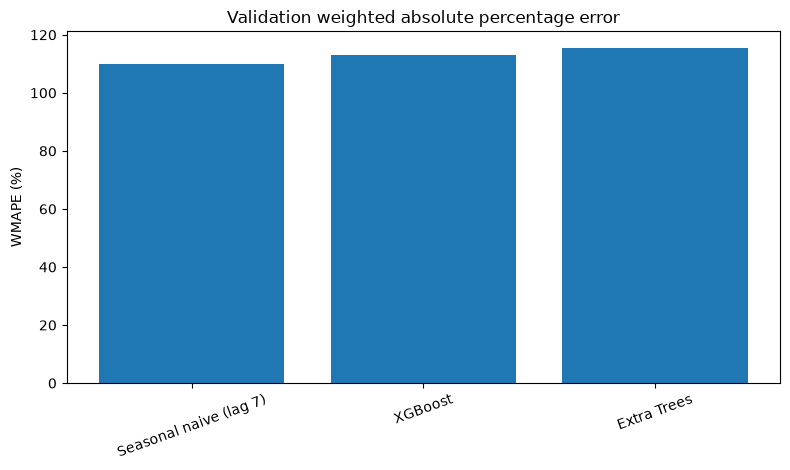

In [10]:
def forecast_metrics(name, y_true, pred):
    y = np.asarray(y_true, dtype=float)
    p = np.asarray(pred, dtype=float)
    mae = mean_absolute_error(y, p)
    rmse = mean_squared_error(y, p) ** 0.5
    wmape = np.abs(y-p).sum() / max(np.abs(y).sum(), 1e-12)
    bias = (p-y).sum() / max(y.sum(), 1e-12)
    return {
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "WMAPE": wmape,
        "forecast_bias": bias
    }

val_results = pd.DataFrame([
    forecast_metrics("Seasonal naive (lag 7)", y_val, val_pred_naive),
    forecast_metrics("Extra Trees", y_val, val_pred_extra),
    forecast_metrics("XGBoost", y_val, val_pred_xgb)
]).set_index("model").sort_values("WMAPE")

display(val_results.style.format({
    "MAE":"{:.2f}","RMSE":"{:.2f}",
    "WMAPE":"{:.2%}","forecast_bias":"{:.2%}"
}))

best_ml_name = val_results.loc[["Extra Trees","XGBoost"], "WMAPE"].idxmin()
val_pred_best = val_pred_xgb if best_ml_name == "XGBoost" else val_pred_extra
print(f"Selected ML model for deployment: {best_ml_name}")

fig, ax = plt.subplots(figsize=(8, 4.8))
plot_df = val_results.sort_values("WMAPE")
ax.bar(plot_df.index, plot_df["WMAPE"] * 100)
ax.set_title("Validation weighted absolute percentage error")
ax.set_ylabel("WMAPE (%)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 7. One-time final test evaluation

In [11]:
test_pred_extra = np.clip(extra.predict(X_test), 0, None)
test_pred_xgb = np.clip(xgb.predict(X_test), 0, None)
test_pred_naive = np.clip(test_df["lag_7"].to_numpy(), 0, None)

test_pred_best = test_pred_xgb if best_ml_name == "XGBoost" else test_pred_extra

test_results = pd.DataFrame([
    forecast_metrics("Seasonal naive (lag 7)", y_test, test_pred_naive),
    forecast_metrics("Extra Trees", y_test, test_pred_extra),
    forecast_metrics("XGBoost", y_test, test_pred_xgb)
]).set_index("model").sort_values("WMAPE")

display(test_results.style.format({
    "MAE":"{:.2f}","RMSE":"{:.2f}",
    "WMAPE":"{:.2%}","forecast_bias":"{:.2%}"
}))

selected_test = test_results.loc[best_ml_name]
print(f"""
FINAL FORECAST RESULT
---------------------
Selected model: {best_ml_name}
Test MAE: {selected_test['MAE']:.2f} units / SKU-day
Test RMSE: {selected_test['RMSE']:.2f}
Test WMAPE: {selected_test['WMAPE']:.2%}
Forecast bias: {selected_test['forecast_bias']:.2%}
""")

,MAE,RMSE,WMAPE,forecast_bias
model,,,,
Seasonal naive (lag 7),172.09,2359.45,107.13%,-40.50%
XGBoost,177.89,2357.30,110.74%,-32.69%
Extra Trees,207.52,2425.20,129.19%,-20.27%



FINAL FORECAST RESULT
---------------------
Selected model: XGBoost
Test MAE: 177.89 units / SKU-day
Test RMSE: 2357.30
Test WMAPE: 110.74%
Forecast bias: -32.69%



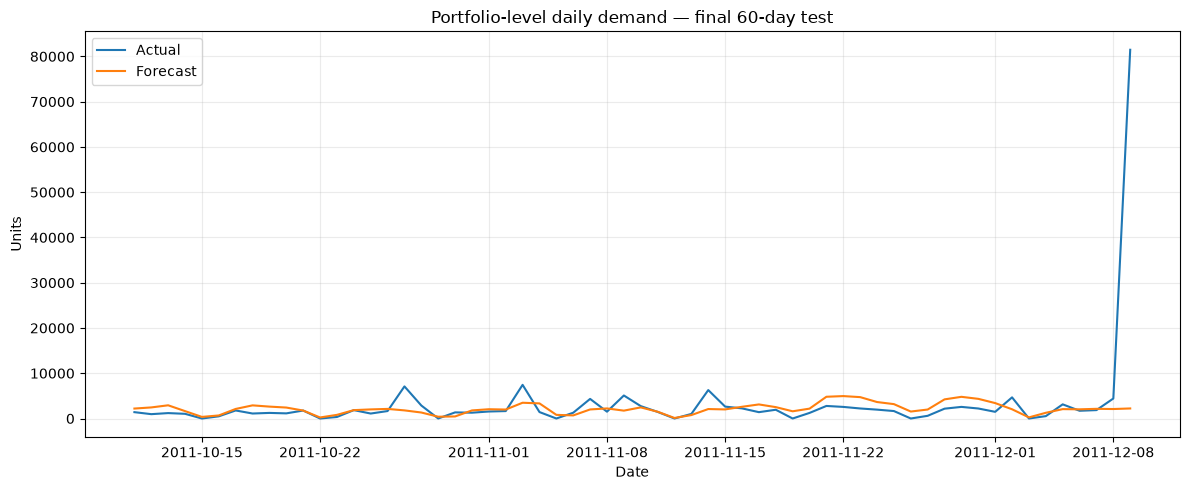

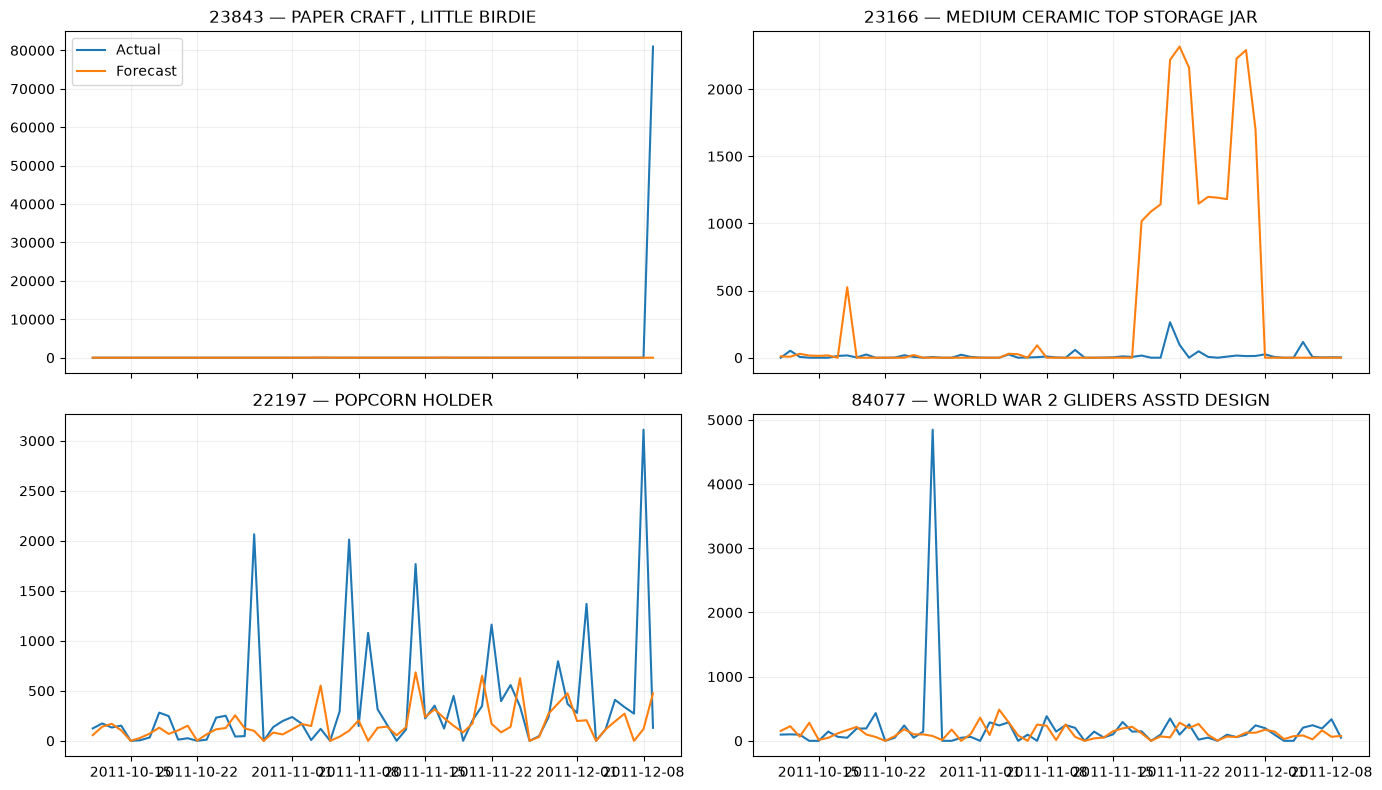

In [12]:
test_plot = test_df[["date","StockCode","Description","demand"]].copy()
test_plot["prediction"] = test_pred_best

actual_total = test_plot.groupby("date")["demand"].sum()
pred_total = test_plot.groupby("date")["prediction"].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(actual_total.index, actual_total.values, label="Actual")
ax.plot(pred_total.index, pred_total.values, label="Forecast")
ax.set_title("Portfolio-level daily demand — final 60-day test")
ax.set_ylabel("Units")
ax.set_xlabel("Date")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

top4_codes = product_summary.head(4).index.get_level_values(0).tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, sku in zip(axes.ravel(), top4_codes):
    d = test_plot.loc[test_plot["StockCode"] == sku]
    desc = d["Description"].iloc[0][:32]
    ax.plot(d["date"], d["demand"], label="Actual")
    ax.plot(d["date"], d["prediction"], label="Forecast")
    ax.set_title(f"{sku} — {desc}")
    ax.grid(alpha=0.2)
axes[0,0].legend()
plt.tight_layout()
plt.show()

## 8. Explainability — what drives the demand forecast?

,importance
week,0.232
dow_cos,0.140
dow,0.127
dow_sin,0.100
day_of_month,0.100
SKU identity,0.077
month_cos,0.061
month,0.059
is_weekend,0.028
lag_price_1,0.020


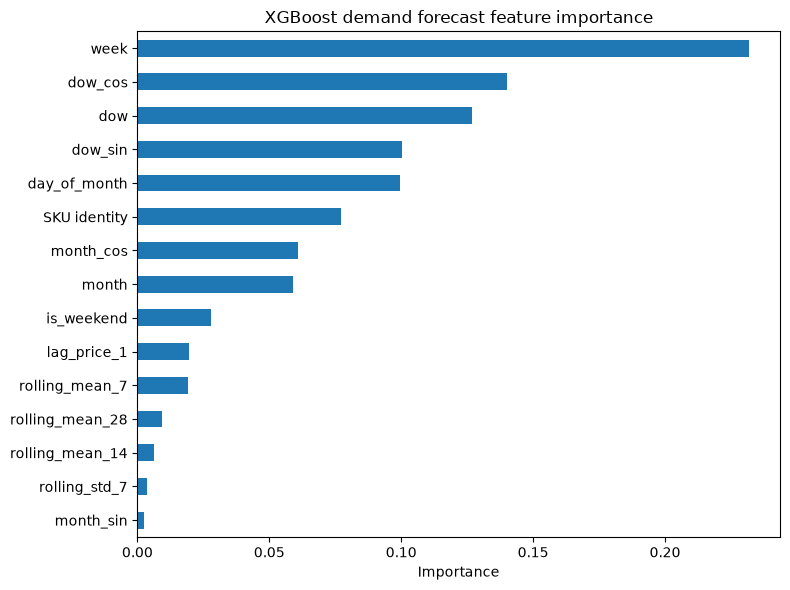

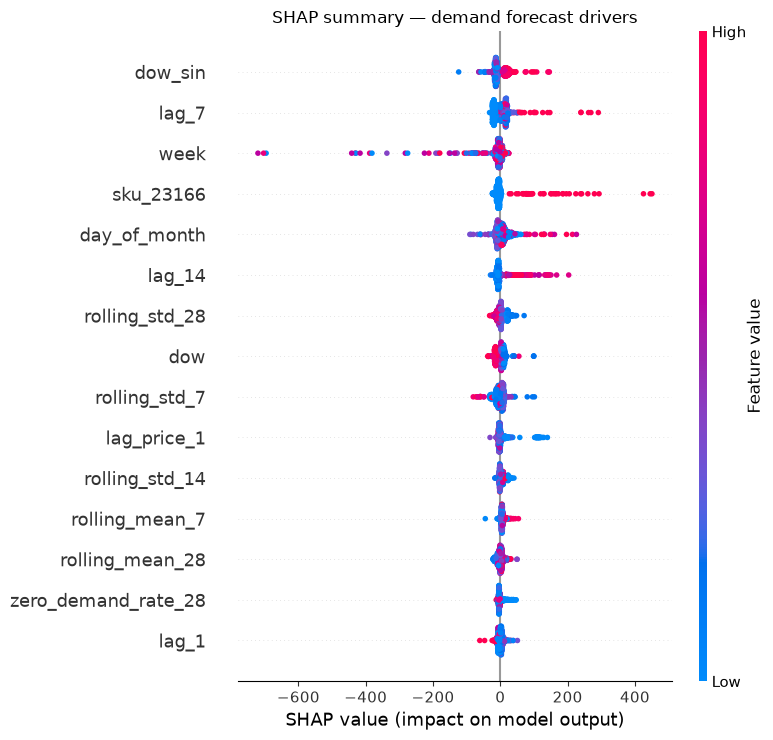

In [13]:
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Aggregate all SKU dummy importances into one readable family.
readable = {}
for feature, value in xgb_importance.items():
    key = "SKU identity" if feature.startswith("sku_") else feature
    readable[key] = readable.get(key, 0.0) + float(value)

readable_importance = pd.Series(readable).sort_values(ascending=False).head(15)
display(readable_importance.to_frame("importance"))

fig, ax = plt.subplots(figsize=(8, 6))
readable_importance.sort_values().plot(kind="barh", ax=ax)
ax.set_title("XGBoost demand forecast feature importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

import shap
sample_for_shap = X_val.sample(min(1000, len(X_val)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(sample_for_shap)
shap.summary_plot(shap_values, sample_for_shap, max_display=15, show=False)
plt.title("SHAP summary — demand forecast drivers")
plt.tight_layout()
plt.show()

## 9. Convert forecast uncertainty into safety stock

Inventory assumptions are explicit and illustrative:
- 7-day supplier lead time
- 95% cycle-service target
- safety stock based on validation residual uncertainty

This is an inventory policy simulation, not a claim about the retailer's actual stock levels.

In [14]:
LEAD_TIME_DAYS = 7
SERVICE_Z = 1.645

val_policy = val_df[["date","StockCode","demand","rolling_mean_7"]].copy()
val_policy["prediction"] = val_pred_best
val_policy["residual"] = val_policy["demand"] - val_policy["prediction"]

resid_std = (
    val_policy.groupby("StockCode")["residual"]
    .std()
    .fillna(val_policy["residual"].std())
)

policy = test_df[[
    "date","StockCode","Description","demand","rolling_mean_7"
]].copy()
policy["forecast"] = test_pred_best
policy["residual_std"] = policy["StockCode"].map(resid_std).fillna(resid_std.mean())
policy["safety_stock"] = (
    SERVICE_Z * policy["residual_std"] * np.sqrt(LEAD_TIME_DAYS)
)
policy["recommended_target"] = (
    policy["forecast"] * LEAD_TIME_DAYS + policy["safety_stock"]
)
policy["baseline_target"] = (
    policy["rolling_mean_7"].clip(lower=0) * LEAD_TIME_DAYS
)

# Actual demand over the next 7 days, used only for retrospective simulation.
policy = policy.sort_values(["StockCode","date"]).reset_index(drop=True)
policy["actual_7d_demand"] = (
    policy.groupby("StockCode")["demand"]
    .transform(lambda s: s.iloc[::-1].rolling(LEAD_TIME_DAYS, min_periods=LEAD_TIME_DAYS).sum().iloc[::-1])
)

sim = policy.dropna(subset=["actual_7d_demand"]).copy()

sim["baseline_shortage"] = np.maximum(
    sim["actual_7d_demand"] - sim["baseline_target"], 0
)
sim["recommended_shortage"] = np.maximum(
    sim["actual_7d_demand"] - sim["recommended_target"], 0
)
sim["baseline_excess"] = np.maximum(
    sim["baseline_target"] - sim["actual_7d_demand"], 0
)
sim["recommended_excess"] = np.maximum(
    sim["recommended_target"] - sim["actual_7d_demand"], 0
)

sim["baseline_stockout"] = sim["baseline_shortage"] > 0
sim["recommended_stockout"] = sim["recommended_shortage"] > 0

inventory_summary = pd.DataFrame({
    "policy":["7-day rolling mean","ML forecast + safety stock"],
    "stockout_window_rate":[
        sim["baseline_stockout"].mean(),
        sim["recommended_stockout"].mean()
    ],
    "service_level":[
        1-sim["baseline_stockout"].mean(),
        1-sim["recommended_stockout"].mean()
    ],
    "shortage_units":[
        sim["baseline_shortage"].sum(),
        sim["recommended_shortage"].sum()
    ],
    "avg_target_units":[
        sim["baseline_target"].mean(),
        sim["recommended_target"].mean()
    ]
}).set_index("policy")

display(inventory_summary.style.format({
    "stockout_window_rate":"{:.2%}",
    "service_level":"{:.2%}",
    "shortage_units":"{:,.0f}",
    "avg_target_units":"{:,.1f}"
}))

,stockout_window_rate,service_level,shortage_units,avg_target_units
policy,,,,
7-day rolling mean,45.93%,54.07%,"327,675",635.3
ML forecast + safety stock,17.31%,82.69%,"225,050","1,318.9"


## 10. Inventory cost simulation

The following costs are intentionally illustrative so the business trade-off is transparent rather than hidden:
- £4 penalty per unit of unmet demand
- £0.05 holding cost per excess unit over a 7-day decision window

,illustrative_cost,vs_baseline_change
policy,,
7-day rolling mean,"£1,321,512.40",+0.00%
ML forecast + safety stock,"£942,797.47",-28.66%


Simulated cost change from forecast-driven replenishment: -28.66%


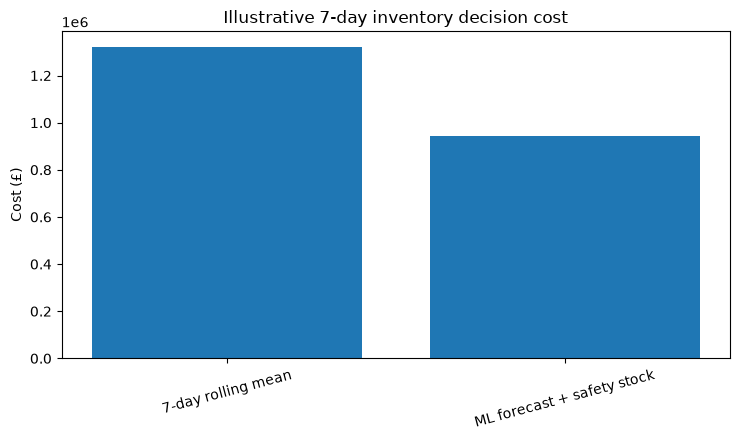

In [15]:
STOCKOUT_COST_PER_UNIT = 4.0
HOLDING_COST_PER_EXCESS_UNIT = 0.05

baseline_cost = (
    sim["baseline_shortage"].sum() * STOCKOUT_COST_PER_UNIT
    + sim["baseline_excess"].sum() * HOLDING_COST_PER_EXCESS_UNIT
)
recommended_cost = (
    sim["recommended_shortage"].sum() * STOCKOUT_COST_PER_UNIT
    + sim["recommended_excess"].sum() * HOLDING_COST_PER_EXCESS_UNIT
)

cost_summary = pd.DataFrame({
    "policy":["7-day rolling mean","ML forecast + safety stock"],
    "illustrative_cost":[baseline_cost, recommended_cost]
}).set_index("policy")
cost_summary["vs_baseline_change"] = (
    cost_summary["illustrative_cost"] / baseline_cost - 1
)

display(cost_summary.style.format({
    "illustrative_cost":"£{:,.2f}",
    "vs_baseline_change":"{:+.2%}"
}))

print(
    f"Simulated cost change from forecast-driven replenishment: "
    f"{(recommended_cost/baseline_cost-1):+.2%}"
)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(cost_summary.index, cost_summary["illustrative_cost"])
ax.set_title("Illustrative 7-day inventory decision cost")
ax.set_ylabel("Cost (£)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## 11. Final replenishment recommendation table

In [16]:
latest_date = policy["date"].max()
latest = policy.loc[policy["date"] == latest_date].copy()

latest["reorder_point_units"] = np.ceil(latest["recommended_target"]).astype(int)
latest["safety_stock_units"] = np.ceil(latest["safety_stock"]).astype(int)
latest["forecast_daily_units"] = latest["forecast"]

latest["uncertainty_ratio"] = (
    latest["safety_stock"] / (latest["forecast"] * LEAD_TIME_DAYS + 1)
)
latest["priority"] = pd.cut(
    latest["uncertainty_ratio"],
    bins=[-np.inf, 0.20, 0.50, np.inf],
    labels=["Standard","Watch","High uncertainty"]
)

recommendations = latest[[
    "StockCode","Description",
    "forecast_daily_units","safety_stock_units",
    "reorder_point_units","priority"
]].sort_values("reorder_point_units", ascending=False)

print(f"Replenishment recommendations generated for {latest_date.date()}:")
display(recommendations.head(20).style.format({
    "forecast_daily_units":"{:.1f}"
}))

recommendations.to_csv("retail_replenishment_recommendations.csv", index=False)
test_results.to_csv("retail_forecast_test_metrics.csv")
inventory_summary.to_csv("retail_inventory_policy_simulation.csv")

print("Decision artefacts exported.")

Replenishment recommendations generated for 2011-12-09:


,StockCode,Description,forecast_daily_units,safety_stock_units,reorder_point_units,priority
479,22197,POPCORN HOLDER,474.7,874,4197,Watch
1019,84879,ASSORTED COLOUR BIRD ORNAMENT,510.8,448,4024,Standard
599,22469,HEART OF WICKER SMALL,185.9,613,1914,Watch
1139,85099B,JUMBO BAG RED RETROSPOT,106.3,991,1735,High uncertainty
359,22086,PAPER CHAIN KIT 50'S CHRISTMAS,137.9,523,1488,High uncertainty
899,47566,PARTY BUNTING,153.8,404,1481,Watch
239,21915,RED HARMONICA IN BOX,30.9,1090,1306,High uncertainty
539,22386,JUMBO BAG PINK POLKADOT,63.4,731,1175,High uncertainty
179,21212,PACK OF 72 RETROSPOT CAKE CASES,76.6,597,1134,High uncertainty
419,22178,VICTORIAN GLASS HANGING T-LIGHT,60.3,702,1125,High uncertainty


Decision artefacts exported.


## 12. Executive summary

In [17]:
baseline_test = test_results.loc["Seasonal naive (lag 7)"]
ml_test = test_results.loc[best_ml_name]
baseline_service = inventory_summary.loc["7-day rolling mean","service_level"]
ml_service = inventory_summary.loc["ML forecast + safety stock","service_level"]

print(f"""
RETAIL DEMAND & INVENTORY EXECUTIVE SUMMARY
-------------------------------------------
Dataset: UCI Online Retail
Modelled SKUs: {panel['StockCode'].nunique()}
Selected ML model: {best_ml_name}
Final test WMAPE: {ml_test['WMAPE']:.2%}
Seasonal-naive test WMAPE: {baseline_test['WMAPE']:.2%}
ML WMAPE change vs naive: {(ml_test['WMAPE']/baseline_test['WMAPE']-1):+.2%}

Baseline simulated service level: {baseline_service:.2%}
Forecast + safety-stock service level: {ml_service:.2%}
Illustrative inventory cost change: {(recommended_cost/baseline_cost-1):+.2%}

The notebook connects forecasting to an operational decision:
historical transactions -> leakage-safe demand features -> forecast ->
uncertainty -> safety stock -> reorder point -> simulated service/cost.
""")


RETAIL DEMAND & INVENTORY EXECUTIVE SUMMARY
-------------------------------------------
Dataset: UCI Online Retail
Modelled SKUs: 20
Selected ML model: XGBoost
Final test WMAPE: 110.74%
Seasonal-naive test WMAPE: 107.13%
ML WMAPE change vs naive: +3.37%

Baseline simulated service level: 54.07%
Forecast + safety-stock service level: 82.69%
Illustrative inventory cost change: -28.66%

The notebook connects forecasting to an operational decision:
historical transactions -> leakage-safe demand features -> forecast ->
uncertainty -> safety stock -> reorder point -> simulated service/cost.



### Production roadmap
- hierarchical forecasts across SKU / category / total business levels;
- probabilistic prediction intervals rather than residual-normal approximations;
- supplier-specific lead times and minimum order quantities;
- promotion, price, holiday and marketing calendars;
- lost-sales estimation rather than treating observed sales as unconstrained demand;
- inventory-on-hand and open-purchase-order integration;
- service-level optimisation by product margin / criticality;
- drift monitoring and automated forecast backtesting.

### Interview defence
**“I treated demand forecasting as a decision problem rather than stopping at RMSE. I used a strict chronological split, lagged every historical-demand feature to prevent leakage, benchmarked against a seasonal naive model, and converted forecast uncertainty into safety stock, reorder points, service-level simulation and an explicit inventory cost trade-off.”**